# import what we need

In [1]:
import os

import pandas as pd
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
# import torchvision.transforms as T
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import random

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image,ImageEnhance

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Read Data, Vectorize them and some other shits

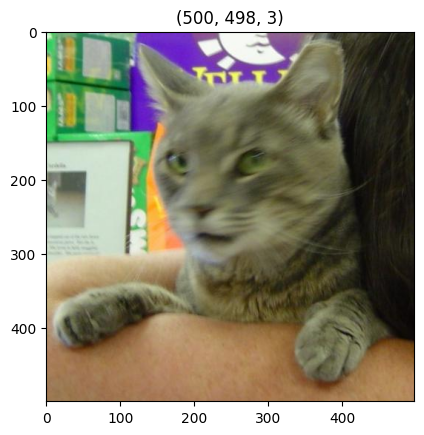

In [2]:
img = mpimg.imread('PetImagesTest/Cat/12484.jpg')
plt.imshow(img)
plt.title(img.shape)
plt.show()

In [3]:
class AddGaussianNoise:
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        if not isinstance(tensor, torch.Tensor):
            raise TypeError("Input must be a torch.Tensor")
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"GaussianNoise(mean={self.mean}, std={self.std})"

In [4]:
def load_and_vectorize_augmented(base_path, target_size=(128, 128), aug_factor=2):
    images = []
    labels = []
    
    for label in ['Cat', 'Dog']:
        folder_path = os.path.join(base_path, label)
        print(f"Loading {label} folder...")
        for img_name in os.listdir(folder_path):
            if img_name.lower().endswith(('.jpg', '.jpeg')):
                img_path = os.path.join(folder_path, img_name)
                try:
                    img = Image.open(img_path).convert('RGB').resize(target_size)
                    img_array = np.array(img, dtype=np.float32) / 255.0
                    images.append(img_array)
                    labels.append(label)
                    
                    if aug_factor > 1:
                        for _ in range(aug_factor-1):
                            aug_img = img.copy()
                            aug_img = aug_img.resize((int(target_size[0]*random.uniform(0.85,1.0)), 
                                                    int(target_size[1]*random.uniform(0.85,1.0))))
                            aug_img = aug_img.resize(target_size)
                            
                            if random.random() < 0.5: aug_img = aug_img.transpose(Image.FLIP_LEFT_RIGHT)
                            angle = random.uniform(-20, 20)
                            aug_img = aug_img.rotate(angle)
                            
                            enhancer = ImageEnhance.Brightness(aug_img)
                            aug_img = enhancer.enhance(random.uniform(0.8, 1.2))
                            enhancer = ImageEnhance.Contrast(aug_img)
                            aug_img = enhancer.enhance(random.uniform(0.8, 1.2))
                            
                            aug_array = np.array(aug_img, dtype=np.float32) / 255.0
                            images.append(aug_array)
                            labels.append(label)
                except:
                    continue
    
    return np.array(images), np.array(labels)


In [5]:
base_path = r'./PetImages/'
X_vectors, y_labels = load_and_vectorize_augmented(base_path, aug_factor=0)
print(f"count: {X_vectors.shape[0]}")
print(f"Vector shape: {X_vectors.shape[1]}")
print(f"Cat: {np.sum(y_labels=='Cat')}, Dog: {np.sum(y_labels=='Dog')}")

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

Loading Cat folder...
Loading Dog folder...
count: 16139
Vector shape: 128
Cat: 7668, Dog: 8471


In [19]:
os.makedirs("Data_Encoded", exist_ok=True)

np.save("Data_Encoded/images_encoded.npy", X_vectors)
np.save("Data_Encoded/y_encoded.npy", y_encoded)

print("Saved Successfully!")


Saved Successfully!


In [20]:
X_vectors.shape

(16139, 128, 128, 3)

# try models and architecture

In [21]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

PyTorch: 2.9.1+cu128
CUDA: True
Device: cuda


In [22]:
X_train, X_val, y_train, y_val = train_test_split(X_vectors, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

X_train_tensor = torch.FloatTensor(X_train.transpose(0,3,1,2))  # (N,C,H,W)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val.transpose(0,3,1,2))
y_val_tensor = torch.LongTensor(y_val)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [23]:
class ResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        dropout=0.0
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.dropout = nn.Dropout2d(dropout)

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity

        out = F.relu(out)

        return out

In [24]:
class BetterCatDogCNN(nn.Module):

    def __init__(self, num_classes=2):

        super().__init__()

        # 128x128
        self.stem = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # 64x64
        self.layer1 = nn.Sequential(

            ResidualBlock(
                32,
                32,
                stride=1,
                dropout=0.05
            ),

            ResidualBlock(
                32,
                32,
                stride=1,
                dropout=0.05
            )
        )

        # 32x32
        self.layer2 = nn.Sequential(

            ResidualBlock(
                32,
                64,
                stride=2,
                dropout=0.10
            ),

            ResidualBlock(
                64,
                64,
                stride=1,
                dropout=0.10
            )
        )

        # 16x16
        self.layer3 = nn.Sequential(

            ResidualBlock(
                64,
                128,
                stride=2,
                dropout=0.15
            ),

            ResidualBlock(
                128,
                128,
                stride=1,
                dropout=0.15
            )
        )

        # 8x8
        self.layer4 = nn.Sequential(

            ResidualBlock(
                128,
                256,
                stride=2,
                dropout=0.20
            ),

            ResidualBlock(
                256,
                256,
                stride=1,
                dropout=0.20
            )
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.4),

            nn.Linear(256, 64),

            nn.ReLU(inplace=True),

            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

In [25]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = BetterCatDogCNN(num_classes=2)

model = model.to(device)

print(model)

BetterCatDogCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout2d(p=0.05, inplace=False)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum

In [26]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [27]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

In [28]:
def train_model_light(model, train_loader, val_loader, epochs=20, lr=0.0005):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    patience, patience_counter = 10, 0
    
    accumulation_steps = 4
    effective_batch_size = 64 * accumulation_steps
    
    # Mixed Precision (CUDA)
    if torch.cuda.is_available():
        from torch.cuda.amp import autocast, GradScaler
        scaler = GradScaler()
        use_amp = True
    else:
        use_amp = False
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        optimizer.zero_grad()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            
            if use_amp:
                with autocast():
                    output = model(data)
                    loss = criterion(output, target) / accumulation_steps
                scaler.scale(loss).backward()
                
                if (batch_idx + 1) % accumulation_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                output = model(data)
                loss = criterion(output, target) / accumulation_steps
                loss.backward()
                
                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()
            
            train_loss += loss.item() * accumulation_steps
            pred = output.argmax(dim=1)
            train_correct += pred.eq(target).sum().item()
            train_total += target.size(0)
            
            if batch_idx % 100 == 0:
                print(f'Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}')
        
        train_loss /= len(train_loader)
        train_acc = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
                
                if use_amp:
                    with autocast():
                        output = model(data)
                        loss = criterion(output, target)
                else:
                    output = model(data)
                    loss = criterion(output, target)
                
                val_loss += loss.item()
                pred = output.argmax(dim=1)
                val_correct += pred.eq(target).sum().item()
                val_total += target.size(0)
        
        val_loss /= len(val_loader)
        val_acc = 100. * val_correct / val_total
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'  -> New best model saved! (Acc: {val_acc:.2f}%)')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    return {'train_losses': train_losses, 'val_losses': val_losses, 
            'train_accs': train_accs, 'val_accs': val_accs, 'best_val_acc': best_val_acc}

# Create DataLoaders with minimal settings to avoid NumPy issues
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

# Train the model
history = train_model_light(model, train_loader, val_loader)

Epoch 1 | Batch 0/202 | Loss: 0.1800


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23600\4037682763.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23600\4037682763.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Batch 100/202 | Loss: 0.1656
Epoch 1 | Batch 200/202 | Loss: 0.1791


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23600\4037682763.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Train Loss: 0.6579, Acc: 61.29% | Val Loss: 0.6154, Val Acc: 64.19%
  -> New best model saved! (Acc: 64.19%)
Epoch 2 | Batch 0/202 | Loss: 0.1595
Epoch 2 | Batch 100/202 | Loss: 0.1583
Epoch 2 | Batch 200/202 | Loss: 0.1545
Epoch 2: Train Loss: 0.6147, Acc: 66.18% | Val Loss: 0.5772, Val Acc: 68.62%
  -> New best model saved! (Acc: 68.62%)
Epoch 3 | Batch 0/202 | Loss: 0.1423
Epoch 3 | Batch 100/202 | Loss: 0.1391
Epoch 3 | Batch 200/202 | Loss: 0.1336
Epoch 3: Train Loss: 0.5612, Acc: 70.69% | Val Loss: 0.5124, Val Acc: 73.95%
  -> New best model saved! (Acc: 73.95%)
Epoch 4 | Batch 0/202 | Loss: 0.1650
Epoch 4 | Batch 100/202 | Loss: 0.1061
Epoch 4 | Batch 200/202 | Loss: 0.0974
Epoch 4: Train Loss: 0.5000, Acc: 75.73% | Val Loss: 0.4489, Val Acc: 79.43%
  -> New best model saved! (Acc: 79.43%)
Epoch 5 | Batch 0/202 | Loss: 0.1186
Epoch 5 | Batch 100/202 | Loss: 0.0802
Epoch 5 | Batch 200/202 | Loss: 0.0763
Epoch 5: Train Loss: 0.4496, Acc: 79.37% | Val Loss: 0.4140, Val Acc

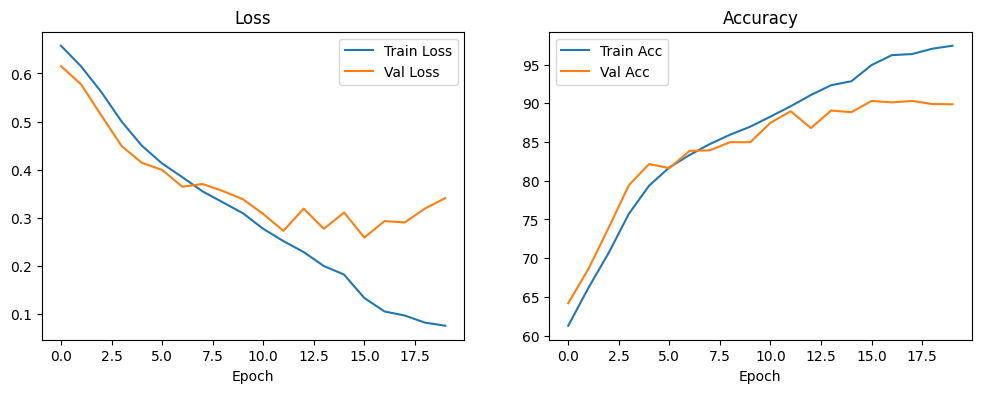

In [29]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['val_losses'], label='Val Loss')
plt.legend(); plt.title('Loss'); plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history['train_accs'], label='Train Acc')
plt.plot(history['val_accs'], label='Val Acc')
plt.legend(); plt.title('Accuracy'); plt.xlabel('Epoch')
plt.show()

In [30]:
def predict_image(image_path, model, device, target_size=(128, 128)):
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(target_size)
    img_array = np.array(img_resized, dtype=np.float32) / 255.0   # [0,1] scaling
    
    img_tensor = torch.FloatTensor(img_array).permute(2, 0, 1).unsqueeze(0)
    img_tensor = img_tensor.to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_class_idx = np.argmax(probs)
    
    class_names = ['Cat', 'Dog']
    predicted_label = class_names[pred_class_idx]
    confidence = probs[pred_class_idx]
    
    return predicted_label, confidence, probs

In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = BetterCatDogCNN(
    num_classes=2
)

model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location="cpu"
    )
)

model = model.to(device)

model.eval()

print("Model loaded successfully!")
print("Device:", next(model.parameters()).device)

Model loaded successfully!
Device: cuda:0


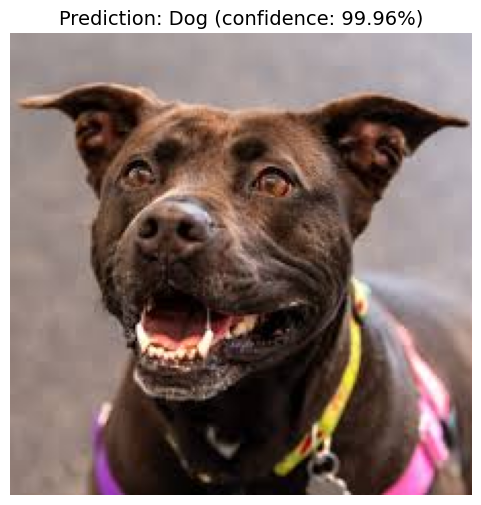

Class probabilities: Cat=0.0004, Dog=0.9996
Final decision: Dog with 99.96% confidence


In [35]:
image_path = 'images.jpg'

pred_label, confidence, probs = predict_image(image_path, model, device)

img_display = Image.open(image_path)
plt.figure(figsize=(6, 6))
plt.imshow(img_display)
plt.title(f"Prediction: {pred_label} (confidence: {confidence:.2%})", fontsize=14)
plt.axis('off')
plt.show()

print(f"Class probabilities: Cat={probs[0]:.4f}, Dog={probs[1]:.4f}")
print(f"Final decision: {pred_label} with {confidence:.2%} confidence")

In [51]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.fh = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach())
        )
        self.bh = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def generate(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1))[0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = F.interpolate(cam[None, None], size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        return cam.cpu().numpy(), class_idx, logits.detach()

    def remove(self):
        self.fh.remove()
        self.bh.remove()

In [48]:
def test_gradcam(model, image_paths, device, target_layer=None, size=(128, 128)):
    names = ["Cat", "Dog"]
    target_layer = target_layer or model.layer4[-1].conv2
    gradcam = GradCAM(model, target_layer)
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))

    for i, path in enumerate(image_paths[:6]):
        img = Image.open(path).convert("RGB")
        resized = img.resize(size, Image.Resampling.BICUBIC)
        arr = np.array(resized, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

        cam, class_idx, logits = gradcam.generate(x)
        prob = torch.softmax(logits, dim=1)[0, class_idx].item()

        axes[0, i].imshow(arr)
        axes[0, i].set_title(f"Image {i}\n{names[class_idx]} ({prob:.1%})")
        axes[0, i].axis("off")

        axes[1, i].imshow(arr)
        axes[1, i].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, i].set_title(f"Grad-CAM {i}\n{names[class_idx]}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()
    gradcam.remove()

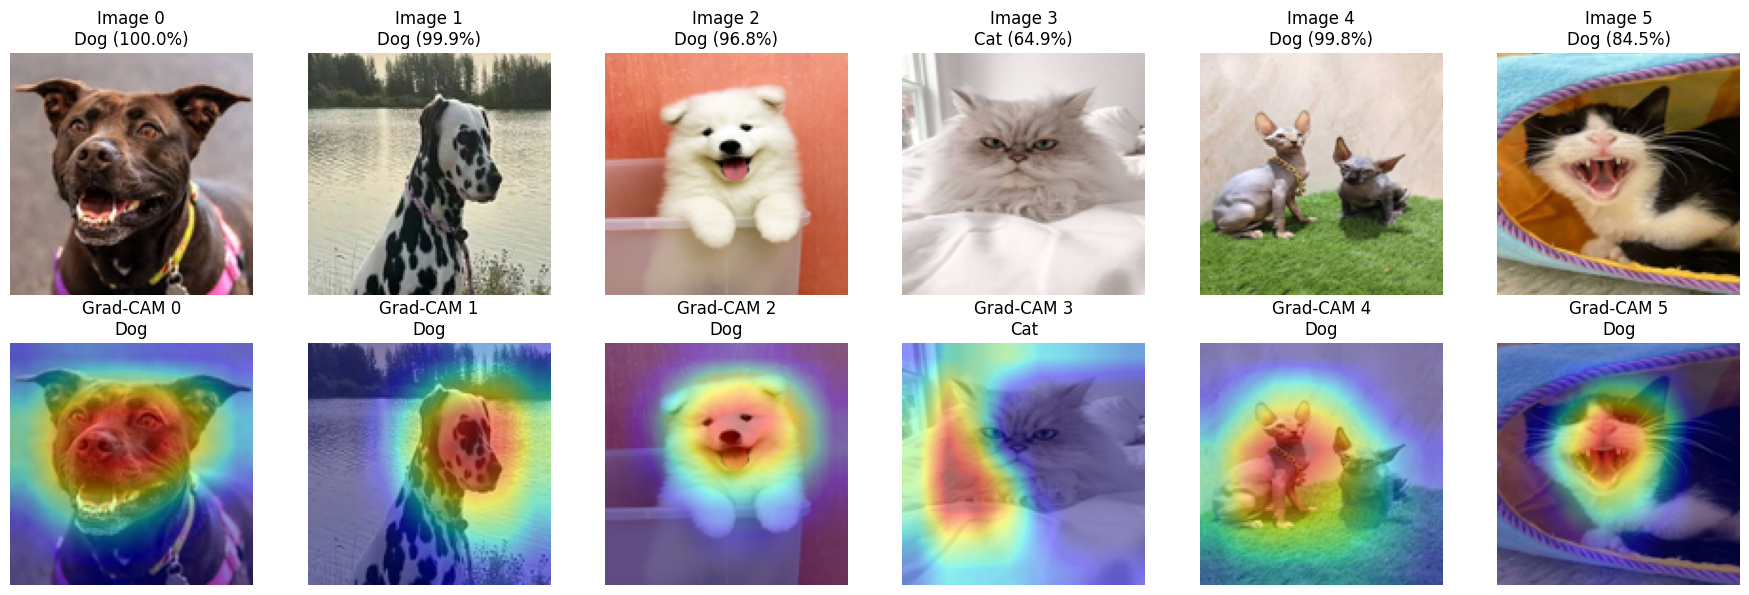

In [54]:
image_paths_test = [
    f"test/image{i}.jpg"
    for i in range(6)
]

test_gradcam(
    model=model,
    image_paths=image_paths_test,
    device=device
)